In [1]:
import sys
sys.path.append("/Users/sujaladhikari/Sujal's Personal/Projects/FedIDS")

In [2]:
import os 
import shutil
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Model.model import MLP
from torch.optim import Adam
import utils
from utils import JoinCustomDataset
from sklearn.metrics import classification_report
from federatedlearning import updatefrom_local, weight_averaging, fednova_update_from_local,fednova_weight_averaging,fed_prox_update_from_local
from nids_training import evaluate_model
import matplotlib.pyplot as plt 
import random

### Setting up the device

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device
RANDOMSEED = 42
random.seed(RANDOMSEED)
np.random.seed(RANDOMSEED)
torch.manual_seed(RANDOMSEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(RANDOMSEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
### Creating a generator to pass into the data loader 
g = torch.Generator()
g.manual_seed(RANDOMSEED)

### Creating the global model - using the same MLP used for the centralized model 

In [4]:
input_size = 78
hidden_layer = [256, 128,64,8]
num_classes = 2
global_model = MLP(input_size, hidden_layer,num_classes).to(device)
global_model
num_clients = 4

### Creating the Data Configuration and Training Configuration 


In [5]:
batch_size = 64 ## Initially we set up as same as the centralized model 
lr = 1e-3 ## different learning rate
num_rounds = 20 ## 5/.0001 => 50000 rounds 
num_local_epochs = 1
save_interval = 1

### Creating the Data Configuration and Training Configuration 


In [6]:
performance_dict, performance_log = dict(), dict()
metric_keys = ['g_train_loss', 'g_test_loss']
performance_dict, performance_log = utils.performance_analyzer(metric_keys)


### Loading each individual client data 

In [7]:
client_directory = '../FederatedAvg/client_data/nids/'
num_clients = 4

In [8]:
client_loaders = [] ## It has four dataloaders for each client 
for index in range(num_clients):
    features_path = f'client_{index}_X_train.csv'
    labels_path = f'client_{index}_y_train.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path) 
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True,generator=g) ## The batch size is 64
    client_loaders.append(dataloader)

### Loading the validation loaders for testing the model's performacen in each epoch in each round 

In [9]:
validation_loaders = []
for index in range(num_clients):
    features_path = f'client_{index}_X_val.csv'
    labels_path = f'client_{index}_y_val.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path)
    print(features_directory,labels_directory)
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True,generator=g)
    validation_loaders.append(dataloader)

../FederatedAvg/client_data/nids/client_0_X_val.csv ../FederatedAvg/client_data/nids/client_0_y_val.csv
../FederatedAvg/client_data/nids/client_1_X_val.csv ../FederatedAvg/client_data/nids/client_1_y_val.csv
../FederatedAvg/client_data/nids/client_2_X_val.csv ../FederatedAvg/client_data/nids/client_2_y_val.csv
../FederatedAvg/client_data/nids/client_3_X_val.csv ../FederatedAvg/client_data/nids/client_3_y_val.csv


In [10]:
### We will be testing the model in the global dataset, which is the same dataset used to test centralized model and federated model
global_dataset = pd.read_csv('../datasets/global_test_dataset.csv')
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


### Resuming from the check point 

In [11]:
saving_directory = '../FederatedProx/output_prox/'

In [12]:
# Checking if there is already anything going on 
log_path = os.path.join(saving_directory, 'performanance_log.pickle')
if os.path.isfile(log_path):
    performance_log = utils.loading_pickle(log_path)
starting_round = len(performance_log[metric_keys[0]]) ## Check the list of the stored values (g_train), if the value is greaeter thean 0 then the model is already started and doing its job, and if the model crashes then it can continue from where it left!
if starting_round > 0:
    global_model.load_state_dict(torch.load(os.path.join(saving_directory, 'g_r_{}.pth').format(starting_round))) ## The global model takes the weight from where it left 

In [13]:
global_weights = global_model.state_dict() ## This gives the initial weights of the given model
loss_function = nn.CrossEntropyLoss()
optimization_args = {'lr':lr}

### Starting of the model 

### We wll be looping the model from start round to number of rounds
### Here the starting round is initially zero as nothing is loaded in the given model 

for round_number in range(starting_round, num_rounds): ## Initially 0 -> 5
    print('Round Number:', round_number) 
    global_model.train()
    client_updates = dict() ## We will be storing the updates given by clients in a dictionary 
    for client_number in range(num_clients): ## Looping through each client
        print('Client:', client_number) ## Printing out the client number 
        client_loader = client_loaders[client_number] ## Loading the each client data 
        validation_loader = validation_loaders[client_number] ## Loading each validation data 
        client_update = fed_prox_update_from_local(global_model,client_loader, validation_loader, num_local_epochs, optimization_args) 
        client_updates.setdefault('local_weights', list()).append(client_update['local_weights'])
        client_updates.setdefault('num_samples', list()).append(client_update['num_samples'])

        ## Performance log update 
        performance_log.setdefault('c_{}_train_loss'.format(client_number), list()).append(client_update['train_loss'])
        ## Train loss of each client using the global model on training data 
        performance_log.setdefault('c_{}_test_loss'.format(client_number), list()).append(client_update['test_loss'])

    
    global_weights = weight_averaging(client_updates['local_weights'], client_updates['num_samples'], device)
    global_model.load_state_dict(global_weights) ## Updating the weights to the global model 

    ## Evaluating the global model on local dataset in each round 
    for client_index in range(num_clients):
        g_train_loss = evaluate_model(global_model, client_loaders[client_index], loss_function, tqdm_desc = 'g_train_loss')
        print(g_train_loss)
        performance_dict['g_train_loss'].update_state(g_train_loss)
        g_test_loss = evaluate_model(global_model, validation_loaders[client_index], loss_function, tqdm_desc='Validation Loss' )
        performance_dict['g_test_loss'].update_state(g_test_loss)
    
    performance_log['g_train_loss'].append(performance_dict['g_train_loss'].result())
    performance_log['g_test_loss'].append(performance_dict['g_test_loss'].result())
    performance_dict['g_train_loss'].reset_state()
    performance_dict['g_test_loss'].reset_state()

    for metric in metric_keys:
        print(f"{metric}: {performance_log[metric][-1]}")

    ## Saving the global model 

    if (round_number + 1)  % save_interval == 0: 
        torch.save(global_model.state_dict(), os.path.join(saving_directory, 'g_r_{}.pth'.format(round_number+1))) ## Saving the global model's weights in the given directory with the name g_r_1..n.pth
        utils.savein_pickle(log_path,performance_log)  ## Storing the overall value in the pickle form to access it later 
    

### Analyzing the model on different silos

In [14]:
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    total = 0 
    correct = 0 
    true_labels = []
    prediction = []

    with torch.no_grad():
        for samples, features in test_loader:
            samples = samples.to(device)
            features = features.to(device)
            output = model(samples)
            loss = criterion(output, features)
            _, predicted = output.max(1)
            prediction.extend(predicted.tolist())
            total += features.size(0)
            test_loss += loss.item()
            correct += predicted.eq(features).sum().item()
            true_labels.extend(features.tolist())

        test_loss = test_loss/len(test_loader.dataset)
        accuracy = 100* correct / total 
    
    return test_loss, accuracy, prediction, true_labels

### Analyzing the federated Prox in each silos 


In [15]:
scaler = StandardScaler()
def batch_maker(dataset):
    dataset = dataset.drop(columns = 'Unnamed: 0', errors='ignore')
    X = dataset.drop(columns = 'Label_Binary')
    X = X.to_numpy()
    y = dataset['Label_Binary']
    y = y.to_numpy()
    X_train , X_test, y_train, y_test = train_test_split(X,y , test_size=0.3, random_state=42)
    X_train = scaler.fit_transform(X_train)
    X_train = torch.tensor(X_train, dtype = torch.float32)
    y_train = torch.tensor(y_train, dtype = torch.long)

    X_test = scaler.transform(X_test)
    X_test = torch.tensor(X_test, dtype = torch.float32)
    y_test = torch.tensor(y_test, dtype = torch.long)

    training_batch = DataLoader(TensorDataset(X_train,y_train), batch_size = 64, shuffle = True,generator=g)
    testing_batch = DataLoader(TensorDataset(X_test,y_test), batch_size=64, shuffle=False,generator=g)
    
    return training_batch,testing_batch 

In [16]:
siloOne_train, siloOne_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryOne.csv'))
siloTwo_train, siloTwo_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryTwo.csv'))
siloThree_train, siloThree_test= batch_maker(pd.read_csv('../silos_datasets/siloBinaryThree.csv'))
siloFour_train, siloFour_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryFour.csv'))


In [17]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloOne_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0026, Test Accuracy: 92.6014%
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     75551
           1       0.98      0.87      0.92     75477

    accuracy                           0.93    151028
   macro avg       0.93      0.93      0.93    151028
weighted avg       0.93      0.93      0.93    151028



In [18]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloTwo_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0024, Test Accuracy: 93.2268%
              precision    recall  f1-score   support

           0       0.91      0.97      0.93     86566
           1       0.96      0.90      0.93     86705

    accuracy                           0.93    173271
   macro avg       0.93      0.93      0.93    173271
weighted avg       0.93      0.93      0.93    173271



In [19]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloThree_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0326, Test Accuracy: 54.8795%
              precision    recall  f1-score   support

           0       0.53      0.87      0.66      4207
           1       0.62      0.22      0.33      4093

    accuracy                           0.55      8300
   macro avg       0.58      0.54      0.49      8300
weighted avg       0.58      0.55      0.50      8300



In [20]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloFour_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0578, Test Accuracy: 49.6142%
              precision    recall  f1-score   support

           0       0.51      0.85      0.63       665
           1       0.44      0.12      0.19       631

    accuracy                           0.50      1296
   macro avg       0.47      0.49      0.41      1296
weighted avg       0.47      0.50      0.42      1296



### Generating images 

In [21]:
import pickle
with open('../FederatedProx/output_prox/performanance_log.pickle', 'rb') as f:
    losses = pickle.load(f)

data = pd.DataFrame(losses)
data.index.name = 'Round'
data = data.reset_index()
data.tail()

,Round,g_train_loss,g_test_loss,c_0_train_loss,c_0_test_loss,c_1_train_loss,c_1_test_loss,c_2_train_loss,c_2_test_loss,c_3_train_loss,c_3_test_loss
15,15,1.527890,1.588224,0.035090,0.036599,0.037096,0.037417,0.028317,0.032319,0.109216,7.506266
16,16,1.578173,1.701780,0.026994,0.028165,0.042920,0.043107,0.025853,0.032657,0.098343,5.180954
17,17,1.592265,1.624646,0.036693,0.038609,0.036132,0.036453,0.026799,0.033294,0.092670,8.978421
18,18,1.522918,1.606416,0.029735,0.030082,0.036286,0.036289,0.026445,0.034480,0.080571,0.520866
19,19,1.550749,1.647177,0.026307,0.027622,0.036357,0.036448,0.025093,0.033352,0.087387,8.582157


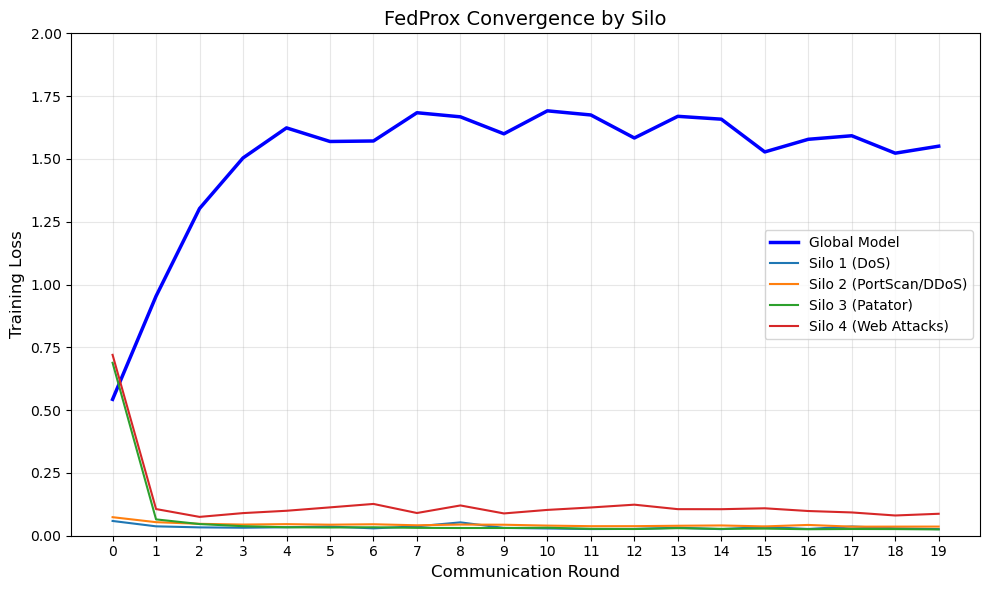

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(data['g_train_loss'], label='Global Model', linewidth=2.5, color='blue')
plt.plot(data['c_0_train_loss'], label='Silo 1 (DoS)', linewidth=1.5)
plt.plot(data['c_1_train_loss'], label='Silo 2 (PortScan/DDoS)', linewidth=1.5)
plt.plot(data['c_2_train_loss'], label='Silo 3 (Patator)', linewidth=1.5)
plt.plot(data['c_3_train_loss'], label='Silo 4 (Web Attacks)', linewidth=1.5)
plt.xticks(np.arange(0,20,1))
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('FedProx Convergence by Silo', fontsize=14)
plt.ylim(0,2)
plt.grid(True, alpha=0.3)  # ← add grid for readability
plt.tight_layout()
plt.legend()
plt.savefig('../modelperformance/fedproxtrain.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


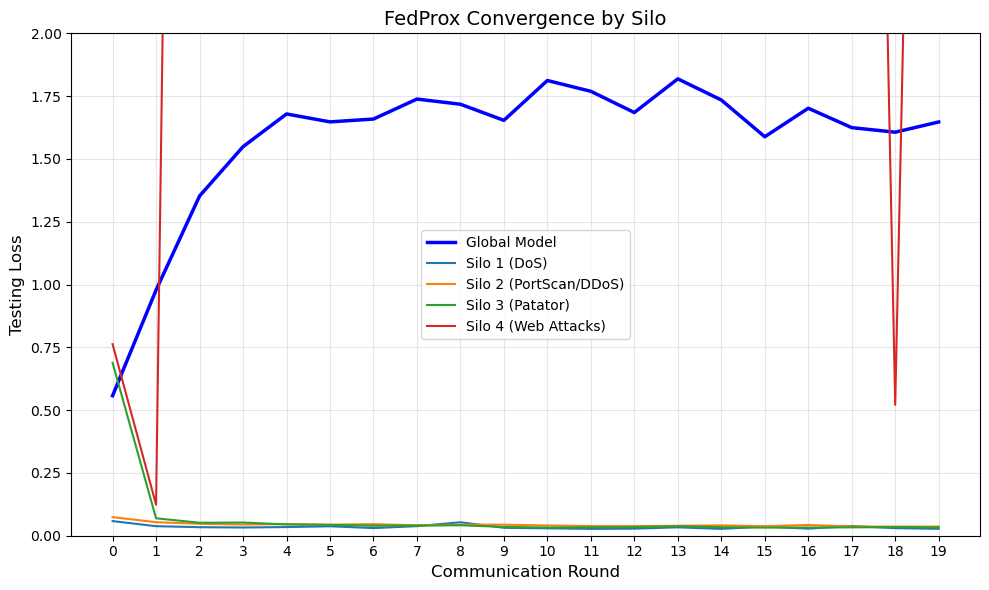

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(data['g_test_loss'], label='Global Model', linewidth=2.5, color='blue')
plt.plot(data['c_0_test_loss'], label='Silo 1 (DoS)', linewidth=1.5)
plt.plot(data['c_1_test_loss'], label='Silo 2 (PortScan/DDoS)', linewidth=1.5)
plt.plot(data['c_2_test_loss'], label='Silo 3 (Patator)', linewidth=1.5)
plt.plot(data['c_3_test_loss'], label='Silo 4 (Web Attacks)', linewidth=1.5)
plt.xticks(np.arange(0,20,1))
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Testing Loss', fontsize=12)
plt.title('FedProx Convergence by Silo', fontsize=14)
plt.ylim(0,2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig('../modelperformance/fedproxtest.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()